In [ ]:
import matplotlib.pyplot as plt
#library for regression model
#using scikitlearn library is basically same as statsmodels.api
import statsmodels.api as sm
import numpy as np
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

qSales = pd.read_csv('qSales_2024.csv')
display(qSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [ ]:
#to do time series foreasting
#Step 0 is always to visualize the data to identify any patterns
#Step 1 is to introduce time as one of our components to the model
#Step 2 introduce any dummy variables you might find
#Step 3 is to do multiple regression modelling

#our focus is to prepare a time series model for apple

In [ ]:
#change date to datetime type

qSales['datadate'] = pd.to_datetime(qSales['datadate'])

In [ ]:
apple_sales = qSales.loc[qSales['tic']=='AAPL']

display(apple_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1690,2022-12-31,2023,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2022Q4,2023Q1,117154.00,A
88,1690,2023-03-31,2023,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q1,2023Q2,94836.00,A
89,1690,2023-06-30,2023,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q2,2023Q3,81797.00,A
90,1690,2023-09-30,2023,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q3,2023Q4,89498.00,A


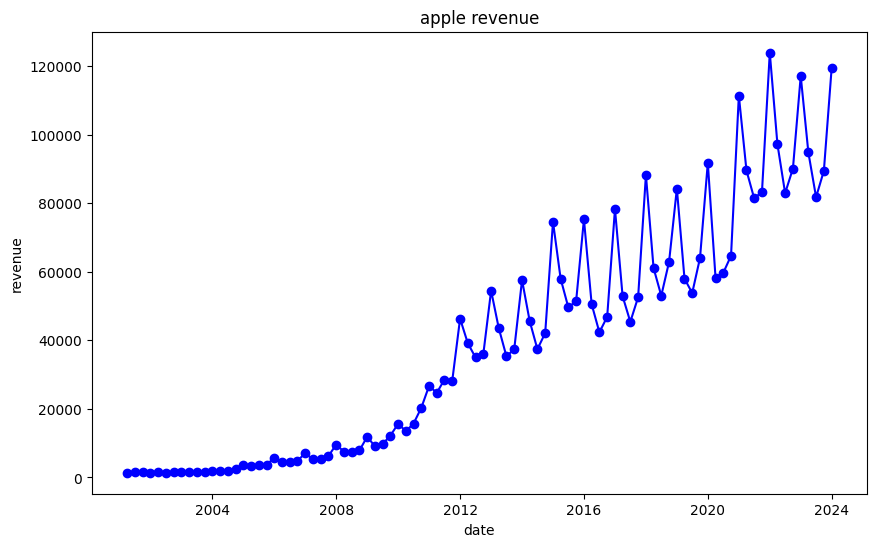

In [ ]:
plt.figure(figsize=(10,6))

plt.title('apple revenue')

plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(apple_sales['datadate'],apple_sales['saleq'],marker = 'o', color = 'blue')

#spikes from new product launches

In [ ]:
#to introduce the time component of time series regression forecasting
#alt we have to do is add a new column - call it time - and measure incrementally increasing time periods (1,2,3,...)

#base requirement is that each row represents an equal block of time (each row is a day or a quarter, etc.)

apple_sales['time'] = range(1, len(apple_sales)+1)
#be sure to add the +1 bc computer starts counting at 0, and we want to capture the last data point as well

display(apple_sales)

/tmp/ipykernel_1621/1162611554.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_sales['time'] = range(1, len(apple_sales)+1)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A,1
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A,2
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A,3
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A,4
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1690,2022-12-31,2023,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2022Q4,2023Q1,117154.00,A,88
88,1690,2023-03-31,2023,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q1,2023Q2,94836.00,A,89
89,1690,2023-06-30,2023,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q2,2023Q3,81797.00,A,90
90,1690,2023-09-30,2023,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q3,2023Q4,89498.00,A,91


In [ ]:
#this is how to take 75% and 25% of the dataset

dt4training = apple_sales[:int(0.75 * len(apple_sales))] #takes the first 75% of rows
dt4testing = apple_sales[int(0.75 * len(apple_sales)):] #takes the last 25% of rows

In [ ]:
y = dt4training.loc[:,'saleq']
x = dt4training.loc[:,'time']

x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,-13536.82
time,1077.61


#during time series forecasting its best to provide a range
#luckily python can take care of that for us

In [ ]:
#to get a range of values we do the following
#create new dataframe with prediction results
#get summary frame with a confidence level

model1_prediction_results = model1.get_prediction(x)
prediction_intervals = model1_prediction_results.summary_frame(alpha=0.2) #80% confidence interval
#higher confidence intervals means that the ranges will also be wider
#80% of confidence recommended

display(prediction_intervals)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,-12459.21,2405.04,-15572.09,-9346.34,-25894.35,975.92
1,-11381.61,2352.57,-14426.58,-8336.64,-24801.17,2037.95
2,-10304.00,2300.54,-13281.62,-7326.39,-23708.44,3100.44
3,-9226.40,2248.95,-12137.24,-6315.55,-22616.16,4163.37
4,-8148.79,2197.84,-10993.50,-5304.09,-21524.33,5226.75
...,...,...,...,...,...,...
64,56507.55,2197.84,53662.84,59352.25,43132.00,69883.09
65,57585.15,2248.95,54674.30,60496.00,44195.38,70974.92
66,58662.76,2300.54,55685.14,61640.37,45258.32,72067.20
67,59740.36,2352.57,56695.39,62785.34,46320.80,73159.93
